In [ ]:
from datasets import load_dataset
from itertools import islice
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from transformers import pipeline
import torch
from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.float_format', '{:,.0f}'.format)

Mounted at /content/drive


In [ ]:
%cd "drive/MyDrive/Colab Notebooks/MIS 769/AnalyzeMe2"

/content/drive/MyDrive/Colab Notebooks/MIS 769/AnalyzeMe2


In [ ]:
# Load the Parquet file (assumes it's in the current working directory)
top10_news_df = pd.read_parquet("top10_stock_news.parquet")

# Quick checks to confirm everything loaded correctly
print("Shape:", top10_news_df.shape)
print("\nColumns:", top10_news_df.columns.tolist())
print("\nUnique tickers:", sorted(top10_news_df['related_symbols'].unique()))
print("\nDate range:",
      top10_news_df['report_date'].min(),
      "to",
      top10_news_df['report_date'].max())
print("\nNumber of rows:", len(top10_news_df))

Shape: (29883, 8)

Columns: ['uuid', 'related_symbols', 'title', 'publisher', 'report_date', 'type', 'link', 'news']

Unique tickers: ['AAPL', 'AMZN', 'FDS', 'GOOG', 'INTC', 'META', 'MSFT', 'NVDA', 'PLTR', 'TSLA']

Date range: 2025-03-12 to 2026-03-15

Number of rows: 29883


In [ ]:
top10_news_df.tail()

,uuid,related_symbols,title,publisher,report_date,type,link,news
29878,823f8723-0fef-32dd-9f22-79bda1f1ded8,TSLA,Tesla receives FTC clearance to convert invest...,TipRanks,2026-03-14,STORY,https://finance.yahoo.com/news/tesla-receives-...,"[{'highlight': '', 'paragraph': 'Filings with ..."
29879,9b688ff8-8490-33b1-b7dc-14cea4338756,TSLA,"Finally, a Little Good News for Tesla Investor...",Motley Fool,2026-03-14,STORY,https://finance.yahoo.com/m/9b688ff8-8490-33b1...,None
29880,caa8d660-b84f-3b21-b94a-79a1f2004489,TSLA,Better EV Stock: Rivian vs. Tesla,Motley Fool,2026-03-15,STORY,https://finance.yahoo.com/m/caa8d660-b84f-3b21...,None
29881,1e141273-c6dc-3156-b851-3f993ccc9ecf,TSLA,BYD Just Announced 5-Minute EV Charging. Shoul...,Motley Fool,2026-03-15,STORY,https://finance.yahoo.com/m/1e141273-c6dc-3156...,None
29882,748afcbc-feff-373d-ae11-15ad2797c645,TSLA,"Elon Musk Bets On Human Workforce As AI, Robot...",Benzinga,2026-03-15,STORY,https://finance.yahoo.com/news/elon-musk-bets-...,"[{'highlight': '', 'paragraph': 'Tesla Inc. CE..."


In [ ]:
print(top10_news_df['news'].apply(type).value_counts())
print("\nExample row 0:", top10_news_df['news'].iloc[0])
print("\nLength of array in row 0:", len(top10_news_df['news'].iloc[0]))

news
<class 'numpy.ndarray'>    28862
<class 'NoneType'>          1021
Name: count, dtype: int64

Example row 0: [{'highlight': 'For Immediate Release', 'paragraph': 'Chicago, IL – March 21, 2025 – Zacks.com announces the list of stocks and ETFs featured in the Analyst Blog. Every day the Zacks Equity Research analysts discuss the latest news and events impacting stocks and the financial markets. Stocks recently featured in the blog include: Apple Inc. AAPL, Meta Platforms, Inc. META, Chevron Corp. CVX, Taylor Devices, Inc. TAYD and GSI Technology, Inc. GSIT.', 'paragraph_number': 1}
 {'highlight': 'Here are highlights from Thursday’s Analyst Blog:', 'paragraph': '', 'paragraph_number': 2}
 {'highlight': 'Top Research Reports for Apple, Meta Platforms and Chevron', 'paragraph': "The Zacks Research Daily presents the best research output of our analyst team. Today's Research Daily features new research reports on 16 major stocks, including Apple Inc., Meta Platforms, Inc. and Chevron Co

In [ ]:
def extract_paragraphs(x):
    if isinstance(x, np.ndarray) and len(x) > 0:
        texts = []
        for item in x:
            if isinstance(item, dict):
                para = item.get('paragraph', '').strip()
                if para:  # skip empty paragraphs
                    texts.append(para)
        return ' '.join(texts) if texts else ''
    return ''

top10_news_df['news_text'] = top10_news_df['news'].apply(extract_paragraphs)

# Now preview properly (no to_string issues with long text)
print("First 2 rows of news_text (truncated):")
for i in range(2):
    text = top10_news_df['news_text'].iloc[i]
    print(f"Row {i}:\n{text[:500]}...\n{'-'*80}\n")

# Global stats
print("Total rows:", len(top10_news_df))
print("Rows with non-empty news_text:", (top10_news_df['news_text'] != '').sum())
print("Rows with empty news_text:", (top10_news_df['news_text'] == '').sum())



First 2 rows of news_text (truncated):
Row 0:
Chicago, IL – March 21, 2025 – Zacks.com announces the list of stocks and ETFs featured in the Analyst Blog. Every day the Zacks Equity Research analysts discuss the latest news and events impacting stocks and the financial markets. Stocks recently featured in the blog include: Apple Inc. AAPL, Meta Platforms, Inc. META, Chevron Corp. CVX, Taylor Devices, Inc. TAYD and GSI Technology, Inc. GSIT. The Zacks Research Daily presents the best research output of our analyst team. Today's Research Dail...
--------------------------------------------------------------------------------

Row 1:
Thursday, March 20, 2025 The Zacks Research Daily presents the best research output of our analyst team. Today's Research Daily features new research reports on 16 major stocks, including Apple Inc. (AAPL), Meta Platforms, Inc. (META) and Chevron Corp. (CVX), as well as two micro-cap stocks Taylor Devices, Inc. (TAYD) and GSI Technology, Inc. (GSIT). The Zack

In [ ]:
# Drop rows where news_text is empty
top10_news_df = top10_news_df[top10_news_df['news_text'] != ''].copy()

# Reset index if you want clean row numbers
top10_news_df = top10_news_df.reset_index(drop=True)

# Quick confirmation
print("Shape after dropping empties:", top10_news_df.shape)
print("Rows with non-empty news_text:", (top10_news_df['news_text'] != '').sum())
print("Unique tickers:", sorted(top10_news_df['related_symbols'].unique()))

Shape after dropping empties: (28862, 9)
Rows with non-empty news_text: 28862
Unique tickers: ['AAPL', 'AMZN', 'FDS', 'GOOG', 'INTC', 'META', 'MSFT', 'NVDA', 'PLTR', 'TSLA']


In [ ]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
# Install transformers (for FinBERT) - run this once
#!pip install -q transformers torch


In [ ]:
sid = SentimentIntensityAnalyzer()

# Compute compound score for each row
top10_news_df['vader_compound'] = top10_news_df['news_text'].apply(
    lambda text: sid.polarity_scores(text)['compound'] if text.strip() else 0.0
)

# Quick check
print("VADER stats:")
print(top10_news_df['vader_compound'].describe())
print("\nSample VADER scores (first 5):")
print(top10_news_df[['related_symbols', 'report_date', 'vader_compound']].head())

VADER stats:
count   28,862
mean         1
std          0
min         -1
25%          0
50%          1
75%          1
max          1
Name: vader_compound, dtype: float64

Sample VADER scores (first 5):
  related_symbols report_date  vader_compound
0            AAPL  2025-03-21               1
1            AAPL  2025-03-21               1
2            AAPL  2025-03-21               1
3            AAPL  2025-03-22               1
4            AAPL  2025-04-02               1


In [ ]:
# Define texts and batch_size (same as before)
texts = top10_news_df['news_text'].tolist()
batch_size = 32  # reduce to 16 or 8 if you get OOM on CPU

# Load pipeline with truncation
device = 0 if torch.cuda.is_available() else -1
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    device=device,
    truncation=True,
    max_length=512
)

# Process in batches
finbert_scores = []

for i in range(0, len(texts), batch_size):
    batch = texts[i:i + batch_size]
    results = sentiment_pipeline(batch)

    for res in results:
        label = res['label']
        score = res['score']
        if label == 'positive':
            finbert_scores.append(score)
        elif label == 'negative':
            finbert_scores.append(-score)
        else:
            finbert_scores.append(0.0)

# Assign to DataFrame
top10_news_df['finbert_score'] = finbert_scores

# Check results
print("FinBERT stats:")
print(top10_news_df['finbert_score'].describe())

print("\nFirst 10 rows with both scores:")
print(top10_news_df[['related_symbols', 'report_date', 'vader_compound', 'finbert_score']].head(10))

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


FinBERT stats:
count   28,862
mean         0
std          1
min         -1
25%         -0
50%          0
75%          1
max          1
Name: finbert_score, dtype: float64

First 10 rows with both scores:
  related_symbols report_date  vader_compound  finbert_score
0            AAPL  2025-03-21               1              1
1            AAPL  2025-03-21               1              1
2            AAPL  2025-03-21               1              1
3            AAPL  2025-03-22               1              1
4            AAPL  2025-04-02               1             -1
5            AAPL  2025-04-03              -1             -1
6            AAPL  2025-04-08               1             -0
7            AAPL  2025-04-09               1              0
8            AAPL  2025-04-12               1             -1
9            AAPL  2025-04-14              -0             -1


In [ ]:
top10_news_df.to_parquet("top10_news_with_sentiment.parquet", index=False)

In [ ]:
top10_news_df.head()

,uuid,related_symbols,title,publisher,report_date,type,link,news,news_text,vader_compound,finbert_score
0,bbf455ff-77a4-32a7-81aa-06dd1d624504,AAPL,"The Zacks Analyst Blog Highlights Apple, Meta ...",Zacks,2025-03-21,STORY,https://finance.yahoo.com/news/zacks-analyst-b...,"[{'highlight': 'For Immediate Release', 'parag...","Chicago, IL – March 21, 2025 – Zacks.com annou...",1,1
1,2cfa6437-c187-3ab8-9ea8-027695257bb0,AAPL,"Top Research Reports for Apple, Meta Platforms...",Zacks,2025-03-21,STORY,https://finance.yahoo.com/news/top-research-re...,"[{'highlight': '', 'paragraph': 'Thursday, Mar...","Thursday, March 20, 2025 The Zacks Research Da...",1,1
2,08501801-66ee-3113-a401-9e991895ffc1,AAPL,"Autodesk in proxy fight, General Mills reports...",TipRanks,2025-03-21,STORY,https://finance.yahoo.com/news/autodesk-proxy-...,"[{'highlight': '', 'paragraph': 'The major ind...",The major indexes were broadly higher near noo...,1,1
3,9fa0933e-573c-36a8-8e69-eacfa956fa70,AAPL,"Accenture reports Q2 beat, Apple TV+ losing $1...",TipRanks,2025-03-22,STORY,https://finance.yahoo.com/news/accenture-repor...,"[{'highlight': '', 'paragraph': 'The major ind...",The major indexes were fractionally higher nea...,1,1
4,e9a0aef3-35a5-38f5-9261-c0e9da5f0052,AAPL,"Rocket acquires Mr. Cooper, Musk’s xAI acquire...",TipRanks,2025-04-02,STORY,https://finance.yahoo.com/news/rocket-acquires...,"[{'highlight': '', 'paragraph': 'The major ave...",The major averages were mostly lower near noon...,1,-1


In [ ]:
top10_news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28862 entries, 0 to 28861
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   uuid             28862 non-null  object        
 1   related_symbols  28862 non-null  object        
 2   title            28862 non-null  object        
 3   publisher        28862 non-null  object        
 4   report_date      28862 non-null  datetime64[ns]
 5   type             28862 non-null  object        
 6   link             28862 non-null  object        
 7   news             28862 non-null  object        
 8   news_text        28862 non-null  object        
 9   vader_compound   28862 non-null  float64       
 10  finbert_score    28862 non-null  float64       
 11  date             28862 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(9)
memory usage: 2.6+ MB


In [ ]:
# Number of unique publishers
num_unique_publishers = top10_news_df['publisher'].nunique()
print(f"Number of unique publishers: {num_unique_publishers}")

# Optional: see what they are and their counts
print("\nTop publishers by article count:")
print(top10_news_df['publisher'].value_counts().head(15))

# Optional: full list if you want to see all
print("\nAll unique publishers:")
print(sorted(top10_news_df['publisher'].unique()))


Number of unique publishers: 155

Top publishers by article count:
publisher
Motley Fool                  3989
MT Newswires                 3625
Zacks                        2057
Barrons.com                  1904
Investor's Business Daily    1397
Simply Wall St.              1262
Insider Monkey               1155
Benzinga                     1061
StockStory                    961
Yahoo Finance Video           887
Yahoo Finance                 872
GuruFocus.com                 849
Bloomberg                     833
The Wall Street Journal       786
GlobeNewswire                 637
Name: count, dtype: int64

All unique publishers:
['24/7 Wall St.', '99bitcoins', 'ACCESS Newswire', 'AFP', 'American Banker', 'Argus Research', 'Associated Press', 'Associated Press Finance', 'Automotive Dive', 'Automotive News', 'Banking Dive', 'Bankrate', 'Barchart', 'Barrons.com', 'BeInCrypto', 'Benzinga', 'Blockspace', 'Bloomberg', 'Business Insider', 'Business Wire', 'C-Store Dive', 'CBS News', 'CCN', 'C

In [ ]:

# 1. Ensure report_date is datetime (run once if not already)
top10_news_df['report_date'] = pd.to_datetime(top10_news_df['report_date'])

# 2. Create a date-only column (no time component)
top10_news_df['date'] = top10_news_df['report_date'].dt.date

# 3. Group by ticker + date and aggregate
daily_sentiment_df = top10_news_df.groupby(
    ['related_symbols', 'date'],
    as_index=False
).agg(
    finbert_mean=('finbert_score', 'mean'),
    vader_mean=('vader_compound', 'mean'),
    article_count=('news_text', 'count')  # number of articles that day
)

# 4. Rename for clarity
daily_sentiment_df = daily_sentiment_df.rename(columns={'related_symbols': 'ticker'})

# 5. Sort by ticker and date for time-series order
daily_sentiment_df = daily_sentiment_df.sort_values(['ticker', 'date'])

# 6. Quick checks
print("Shape of daily_sentiment_df:", daily_sentiment_df.shape)
print("\nUnique tickers:", sorted(daily_sentiment_df['ticker'].unique()))
print("\nDate range:", daily_sentiment_df['date'].min(), "to", daily_sentiment_df['date'].max())
print("\nFirst 10 rows:")
print(daily_sentiment_df.head(10))

# Optional: save it
daily_sentiment_df.to_parquet("daily_sentiment_top10.parquet", index=False)
print("Saved to daily_sentiment_top10.parquet")

Shape of daily_sentiment_df: (2959, 5)

Unique tickers: ['AAPL', 'AMZN', 'FDS', 'GOOG', 'INTC', 'META', 'MSFT', 'NVDA', 'PLTR', 'TSLA']

Date range: 2025-03-12 to 2026-03-15

First 10 rows:
  ticker        date  finbert_mean  vader_mean  article_count
0   AAPL  2025-03-21             1           1              3
1   AAPL  2025-03-22             1           1              1
2   AAPL  2025-04-02            -1           1              1
3   AAPL  2025-04-03            -1          -1              1
4   AAPL  2025-04-08            -0           1              1
5   AAPL  2025-04-09             0           1              1
6   AAPL  2025-04-12            -1           1              1
7   AAPL  2025-04-14             0           0              2
8   AAPL  2025-04-20            -1           1              2
9   AAPL  2025-04-26            -1           0              1
Saved to daily_sentiment_top10.parquet


In [ ]:
# Show more decimal places for the first few rows with apparent -0
print(top10_news_df[top10_news_df['finbert_score'] < 0][['finbert_score']].head(10).to_string(float_format='{:0.6f}'.format))

# Or check min/max in negative territory
print("\nSmallest (most negative) FinBERT scores:")
print(top10_news_df['finbert_score'].nsmallest(5))

print("\nAny exact -0.0?")
print((top10_news_df['finbert_score'] == -0.0).sum())

    finbert_score
4       -0.841902
5       -0.738530
6       -0.473660
8       -0.938943
9       -0.946765
11      -0.956686
12      -0.608772
13      -0.862481
17      -0.974541
18      -0.577381

Smallest (most negative) FinBERT scores:
5500   -1
7633   -1
6337   -1
6183   -1
6018   -1
Name: finbert_score, dtype: float64

Any exact -0.0?
10426


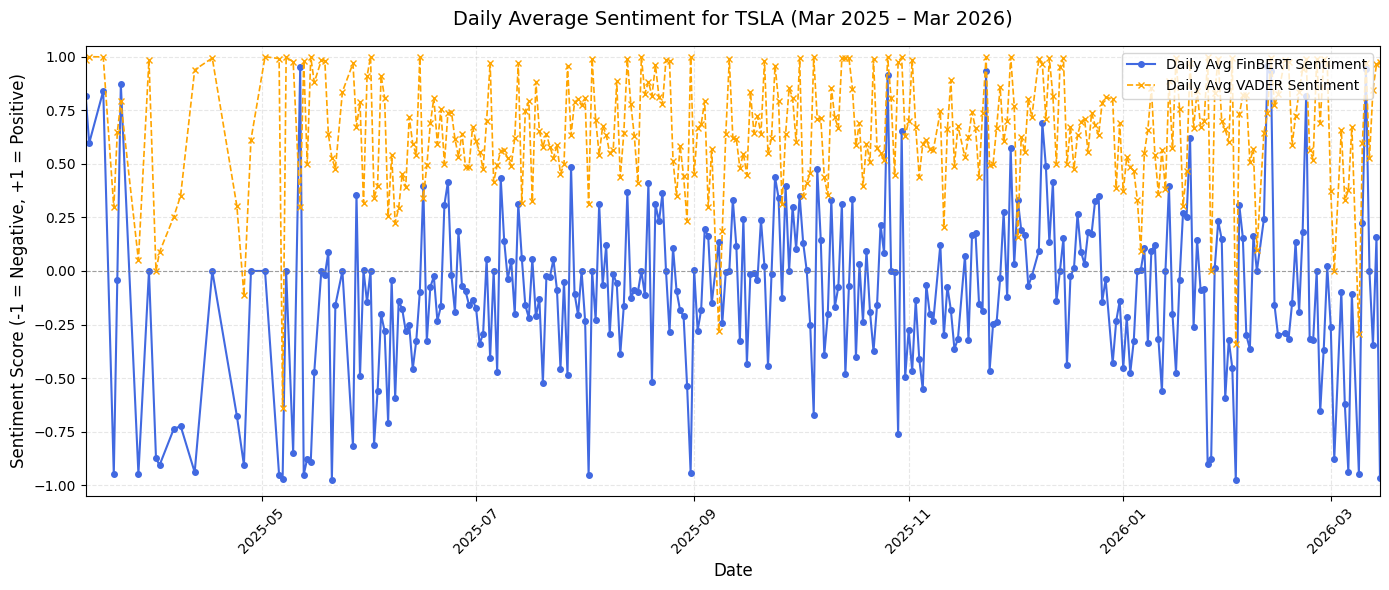

In [ ]:
# Filter to TSLA only
tsla_daily = daily_sentiment_df[daily_sentiment_df['ticker'] == 'TSLA'].copy()

# Make sure date is datetime for proper plotting
tsla_daily['date'] = pd.to_datetime(tsla_daily['date'])

# Sort just in case
tsla_daily = tsla_daily.sort_values('date')

# Create the plot
plt.figure(figsize=(14, 6))

# Line plot for FinBERT mean
plt.plot(tsla_daily['date'], tsla_daily['finbert_mean'],
         marker='o', linestyle='-', color='royalblue', linewidth=1.5, markersize=4,
         label='Daily Avg FinBERT Sentiment')

# Optional: add VADER for comparison (comment out if not wanted)
plt.plot(tsla_daily['date'], tsla_daily['vader_mean'],
         marker='x', linestyle='--', color='orange', linewidth=1.2, markersize=5,
         label='Daily Avg VADER Sentiment')

# Formatting
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7, linewidth=0.8)
plt.ylim(-1.05, 1.05)  # slightly beyond -1/+1 for breathing room
plt.xlim(tsla_daily['date'].min(), tsla_daily['date'].max())

plt.title('Daily Average Sentiment for TSLA (Mar 2025 – Mar 2026)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sentiment Score (-1 = Negative, +1 = Positive)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='upper right', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()